# Fine-tune XLM-RoBERTa trên ViHSD — Text Classifier cho AI Content Moderation (CatSpeak)

**Mục tiêu:** kết quả huấn luyện thật đầu tiên — "lát cắt dọc" chứng minh phương pháp trên **ViHSD** (tiếng Việt, 3 nhãn `CLEAN / OFFENSIVE / HATE`). Các dataset khác (Jigsaw, COLD, VOZ-HSD) sẽ merge sau theo báo cáo v2.

**Môi trường:** Kaggle Notebook hoặc Google Colab **GPU T4** (Runtime → Change runtime type → T4 GPU). Chạy `Run All` từ đầu đến cuối, thời gian huấn luyện dự kiến ~45–90 phút.

**Seed = 42** để tái lập kết quả.

## 1. Setup
Cài thư viện và cố định seed. Kiểm tra GPU trước khi chạy.

In [ ]:
# Cài thư viện cần thiết
!pip install -q transformers datasets evaluate scikit-learn accelerate onnxruntime optimum[onnxruntime]

import random, numpy as np, torch

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "KHONG co GPU — hay bat GPU T4 (Runtime > Change runtime type)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
GPU: Tesla T4


## 2. Load dữ liệu ViHSD
Ưu tiên tải từ Hugging Face `uitnlp/vihsd`; nếu lỗi (yêu cầu đồng ý điều khoản...) thì fallback về bản gốc GitHub `sonlam1102/vihsd`.

Nhãn: `0 = CLEAN`, `1 = OFFENSIVE`, `2 = HATE`.

In [ ]:
from datasets import load_dataset, Dataset, DatasetDict
import pandas as pd

LABELS = ["CLEAN", "OFFENSIVE", "HATE"]

def load_vihsd():
    # Uu tien Hugging Face
    try:
        return load_dataset("uitnlp/vihsd")
    except Exception as e:
        print("HF loi, fallback GitHub:", e)
    # Fallback: clone repo goc, giai nen zip (neu co), tim cac file csv train/dev/test
    import subprocess, glob, zipfile, os
    subprocess.run(["git", "clone", "-q", "https://github.com/sonlam1102/vihsd.git",
                    "/tmp/vihsd_repo"], check=True)
    for z in glob.glob("/tmp/vihsd_repo/**/*.zip", recursive=True):
        with zipfile.ZipFile(z) as f:
            f.extractall("/tmp/vihsd_repo/unzipped")
    csvs = {os.path.basename(p).lower(): p
            for p in glob.glob("/tmp/vihsd_repo/**/*.csv", recursive=True)}
    def pick(*names):
        for n in names:
            for k, p in csvs.items():
                if n in k:
                    return p
        raise FileNotFoundError(f"Khong tim thay csv: {names} trong {list(csvs)}")
    def to_ds(path):
        df = pd.read_csv(path)
        df.columns = [c.strip().lower() for c in df.columns]
        tcol = "free_text" if "free_text" in df.columns else "text"
        lcol = "label_id" if "label_id" in df.columns else "label"
        df = df[[tcol, lcol]].dropna()
        df.columns = ["free_text", "label_id"]
        return Dataset.from_pandas(df, preserve_index=False)
    return DatasetDict(train=to_ds(pick("train")),
                       validation=to_ds(pick("dev", "val")),
                       test=to_ds(pick("test")))

ds = load_vihsd()

# Chuan hoa ten cot ve text / label
for split in ds:
    cols = ds[split].column_names
    if "free_text" in cols:
        ds[split] = ds[split].rename_column("free_text", "text")
    if "label_id" in cols:
        ds[split] = ds[split].rename_column("label_id", "label")

for s in ds:
    print(f"{s}: {len(ds[s]):,} mau")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

HF loi, fallback GitHub: Dataset 'uitnlp/vihsd' is a gated dataset on the Hub. You must be authenticated to access it.
train: 24,046 mau
validation: 2,672 mau
test: 6,680 mau


## 3. EDA nhanh
Phân phối nhãn (sẽ thấy **~82% CLEAN** → đây là lý do phải dùng **weighted loss** ở bước fine-tune), 5 ví dụ mỗi nhãn, và thống kê độ dài câu để chốt `max_length`.

,so mau,ty le %
CLEAN,19885,82.70
OFFENSIVE,1605,6.67
HATE,2556,10.63


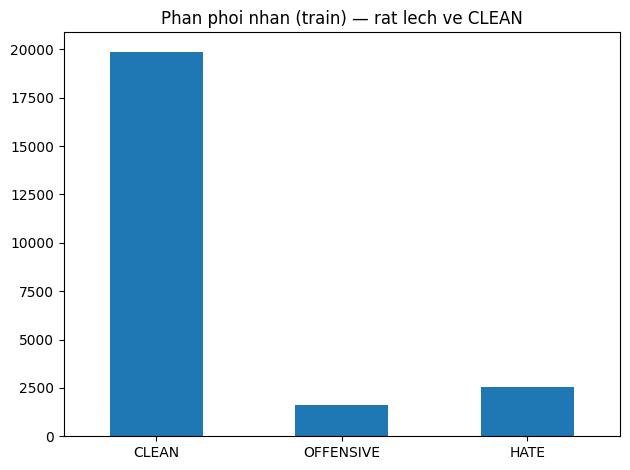


===== CLEAN =====
- Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]]
- Đậu Văn Cường giờ giống thằng sida hơn à
- Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =))
- Coronavirus is manmade
- Đố chúng m nhận ra ai

===== OFFENSIVE =====
- Lúp lúp như chó .
- Dạy bơi cho cá. Bơi thì đương nhiên nó bơi được vì nó là cá. Làm sao cho nó sống được mới là điều người dân đang quan tâ
- Ý thức còn ít hơn cả số tiền trong túi t
- xxx video 🔞
- Đấu khẩu - Chim lợn 👍

===== HATE =====
- Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :)))
- CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.
- Thế mà mình nói mấy thằng bắc kì, bọn đó lại bâu vô nói mình phân biệt!:D
- Loại này cho dựa cột thôi chứ độ thế nào
- Ủa chứ bữa xin lỗi khóc tế om xòm mà giờ chửi nữa rồi bó tay con này hỗn quá

Do dai cau (tu): mean=11.5 | p95=32 | p99=60 | max=1701
=> p95 nho hon nhieu so voi 128 tu -> chon

In [ ]:
import matplotlib.pyplot as plt

df_train = ds["train"].to_pandas()
df_train["label"] = df_train["label"].astype(int)

dist = df_train["label"].value_counts().sort_index()
dist.index = [LABELS[i] for i in dist.index]
tbl = pd.DataFrame({"so mau": dist, "ty le %": (dist / len(df_train) * 100).round(2)})
display(tbl)

tbl["so mau"].plot(kind="bar", title="Phan phoi nhan (train) — rat lech ve CLEAN", rot=0)
plt.tight_layout(); plt.show()

# 5 vi du moi nhan
for i, name in enumerate(LABELS):
    print(f"\n===== {name} =====")
    for t in df_train[df_train.label == i]["text"].astype(str).head(5):
        print("-", t[:120])

# Thong ke do dai cau (theo tu) -> chot max_length
lens = df_train["text"].astype(str).str.split().str.len()
print("\nDo dai cau (tu): mean=%.1f | p95=%d | p99=%d | max=%d"
      % (lens.mean(), lens.quantile(.95), lens.quantile(.99), lens.max()))
print("=> p95 nho hon nhieu so voi 128 tu -> chon max_length=128 la du, train nhanh hon")

## 4. Tiền xử lý
Chuẩn hóa unicode **NFC**, thay URL/mention bằng token đặc biệt. **GIỮ NGUYÊN teencode và từ tục** — đó chính là tín hiệu phân loại, xóa đi là mất thông tin.

In [ ]:
import unicodedata, re

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")

def clean_text(t):
    t = unicodedata.normalize("NFC", str(t))   # chuan hoa unicode NFC
    t = URL_RE.sub(" <URL> ", t)               # URL -> token dac biet
    t = MENTION_RE.sub(" <USER> ", t)          # mention -> token dac biet
    t = re.sub(r"\s+", " ", t).strip()
    return t
    # LUU Y: giu nguyen teencode ("vcl", "dm"...) va tu tuc — tin hieu phan loai

def prep(batch):
    return {"text": [clean_text(x) for x in batch["text"]],
            "label": [int(l) for l in batch["label"]]}

ds = ds.map(prep, batched=True)
print("Vi du sau tien xu ly:", ds["train"][0])

Map:   0%|          | 0/24046 [00:00<?, ? examples/s]

Map:   0%|          | 0/2672 [00:00<?, ? examples/s]

Map:   0%|          | 0/6680 [00:00<?, ? examples/s]

Vi du sau tien xu ly: {'text': 'Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]]', 'label': 0}


## 5. Baseline: TF-IDF + Logistic Regression
Mốc so sánh rẻ tiền (chạy ~1–2 phút). Fine-tune XLM-R phải **vượt** mốc này thì mới đáng công.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

X_train, y_train = ds["train"]["text"], ds["train"]["label"]
X_test,  y_test  = ds["test"]["text"],  ds["test"]["label"]

vec = TfidfVectorizer(ngram_range=(1, 2), max_features=100_000)  # word 1-2 gram
Xtr, Xte = vec.fit_transform(X_train), vec.transform(X_test)

clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)
clf.fit(Xtr, y_train)
pred_base = clf.predict(Xte)

baseline_macro_f1 = f1_score(y_test, pred_base, average="macro")
per_base = f1_score(y_test, pred_base, average=None)
print("=== Baseline TF-IDF + LogisticRegression (test) ===")
print(classification_report(y_test, pred_base, target_names=LABELS, digits=4))
print("Macro-F1 baseline: %.4f" % baseline_macro_f1)

=== Baseline TF-IDF + LogisticRegression (test) ===
              precision    recall  f1-score   support

       CLEAN     0.9491    0.8709    0.9084      5548
   OFFENSIVE     0.3917    0.4482    0.4181       444
        HATE     0.4440    0.6977    0.5427       688

    accuracy                         0.8250      6680
   macro avg     0.5950    0.6723    0.6230      6680
weighted avg     0.8601    0.8250    0.8381      6680

Macro-F1 baseline: 0.6230


## 6. Fine-tune XLM-RoBERTa-base
Custom `Trainer` override `compute_loss` dùng **weighted CrossEntropy** (trọng số nghịch đảo tần suất nhãn) để chống lệch nhãn. Cấu hình theo báo cáo v2: `max_length=128`, `batch=32`, `lr=2e-5`, `warmup 10%`, `3 epoch`, `fp16`, early stopping theo **macro-F1**.

⏱ Dự kiến ~45–90 phút trên T4.

In [ ]:
import inspect
from collections import Counter
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback, set_seed)

set_seed(SEED)
MODEL_NAME = "FacebookAI/xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

ds_tok = ds.map(tokenize, batched=True)

# Trong so nghich dao tan suat nhan (chong lech ~82% CLEAN)
cnt = Counter(ds["train"]["label"])
n_total = sum(cnt.values())
class_weights = torch.tensor(
    [n_total / (len(LABELS) * cnt[i]) for i in range(len(LABELS))], dtype=torch.float)
print("Class weights:", dict(zip(LABELS, class_weights.tolist())))

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS),
    id2label=dict(enumerate(LABELS)), label2id={l: i for i, l in enumerate(LABELS)})

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    out = {"macro_f1": f1_score(labels, preds, average="macro")}
    for i, v in enumerate(f1_score(labels, preds, average=None)):
        out[f"f1_{LABELS[i]}"] = v
    return out

class WeightedTrainer(Trainer):
    """Override compute_loss: weighted CrossEntropy."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

# Tuong thich ten tham so giua cac version transformers
args_kw = dict(
    output_dir="./out", num_train_epochs=3, learning_rate=2e-5,
    per_device_train_batch_size=32, per_device_eval_batch_size=64,
    warmup_ratio=0.1, fp16=torch.cuda.is_available(),
    logging_steps=100, save_total_limit=1, save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    report_to="none", seed=SEED)
sig = inspect.signature(TrainingArguments.__init__).parameters
args_kw["eval_strategy" if "eval_strategy" in sig else "evaluation_strategy"] = "epoch"
training_args = TrainingArguments(**args_kw)

trainer_kw = dict(model=model, args=training_args,
                  train_dataset=ds_tok["train"], eval_dataset=ds_tok["validation"],
                  compute_metrics=compute_metrics,
                  callbacks=[EarlyStoppingCallback(early_stopping_patience=3)])
if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    trainer_kw["processing_class"] = tokenizer
else:
    trainer_kw["tokenizer"] = tokenizer

trainer = WeightedTrainer(**trainer_kw)
trainer.train()

Map:   0%|          | 0/24046 [00:00<?, ? examples/s]

Map:   0%|          | 0/2672 [00:00<?, ? examples/s]

Map:   0%|          | 0/6680 [00:00<?, ? examples/s]

Class weights: {'CLEAN': 0.403084397315979, 'OFFENSIVE': 4.993977069854736, 'HATE': 3.1358892917633057}


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1,F1 Clean,F1 Offensive,F1 Hate
1,0.880300,0.851965,0.590993,0.882410,0.363296,0.527273
2,0.687900,0.740671,0.605908,0.879742,0.401396,0.536585
3,0.556300,0.764699,0.605994,0.877819,0.396396,0.543767


TrainOutput(global_step=2256, training_loss=0.7692384787485109, metrics={'train_runtime': 502.5468, 'train_samples_per_second': 143.545, 'train_steps_per_second': 4.489, 'total_flos': 2396756650357692.0, 'train_loss': 0.7692384787485109, 'epoch': 3.0})

## 7. Đánh giá trên test
Classification report per-class, confusion matrix (heatmap), và bảng so sánh **Baseline vs XLM-R**.

=== XLM-R fine-tuned (test) ===
              precision    recall  f1-score   support

       CLEAN     0.9647    0.8136    0.8828      5548
   OFFENSIVE     0.3037    0.5315    0.3866       444
        HATE     0.4297    0.7645    0.5502       688

    accuracy                         0.7898      6680
   macro avg     0.5661    0.7032    0.6065      6680
weighted avg     0.8657    0.7898    0.8155      6680



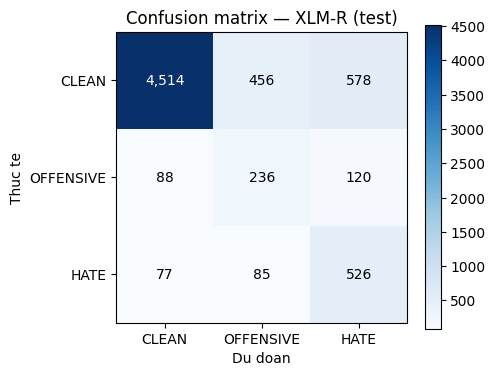

,Baseline TF-IDF+LR,XLM-R fine-tuned
F1 CLEAN,0.9084,0.8828
F1 OFFENSIVE,0.4181,0.3866
F1 HATE,0.5427,0.5502
Macro-F1,0.6230,0.6065


In [ ]:
from sklearn.metrics import confusion_matrix

pred_out = trainer.predict(ds_tok["test"])
preds = pred_out.predictions.argmax(-1)
labels_true = pred_out.label_ids

xlmr_macro_f1 = f1_score(labels_true, preds, average="macro")
per_xlmr = f1_score(labels_true, preds, average=None)
print("=== XLM-R fine-tuned (test) ===")
print(classification_report(labels_true, preds, target_names=LABELS, digits=4))

# Confusion matrix heatmap
cm = confusion_matrix(labels_true, preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), LABELS); ax.set_yticks(range(3), LABELS)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Du doan"); ax.set_ylabel("Thuc te")
ax.set_title("Confusion matrix — XLM-R (test)")
plt.colorbar(im); plt.tight_layout(); plt.show()

# Bang so sanh
compare = pd.DataFrame(
    {"Baseline TF-IDF+LR": list(per_base) + [baseline_macro_f1],
     "XLM-R fine-tuned":   list(per_xlmr) + [xlmr_macro_f1]},
    index=[f"F1 {l}" for l in LABELS] + ["Macro-F1"]).round(4)
display(compare)

if xlmr_macro_f1 > baseline_macro_f1:
    print(f"PASS: XLM-R ({xlmr_macro_f1:.4f}) vuot baseline ({baseline_macro_f1:.4f})")
else:
    print(f"WARNING: XLM-R ({xlmr_macro_f1:.4f}) CHUA vuot baseline ({baseline_macro_f1:.4f}) — kiem tra lai!")

## 8. Demo định tính
Chạy `predict(text)` trên ~10 câu tự đặt: câu sạch, chửi thẳng, teencode/lách từ, và **1 câu tiếng Anh + 1 câu tiếng Trung toxic** — model mới chỉ train tiếng Việt nhưng XLM-R có khả năng **zero-shot cross-lingual** (điểm nói hay khi báo cáo).

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_eval = trainer.model.to(device).eval()

def predict(text):
    enc = tokenizer(clean_text(text), return_tensors="pt",
                    truncation=True, max_length=128).to(device)
    with torch.no_grad():
        probs = torch.softmax(model_eval(**enc).logits, dim=-1)[0].cpu().numpy()
    return LABELS[int(probs.argmax())], {l: round(float(p), 3) for l, p in zip(LABELS, probs)}

demo_texts = [
    "Hôm nay lớp mình học bài mới về thì hiện tại hoàn thành nhé",   # sach
    "Cảm ơn cô giáo, bài giảng dễ hiểu lắm ạ",                       # sach
    "Mai thi nói nhớ mang thẻ học viên nha mọi người",               # sach
    "Thằng này ngu như bò, học mãi không hiểu",                      # chui thang
    "Đồ ng.u, cút đi cho khuất mắt",                                 # lach tu (chen ky tu)
    "vcl thế, làm ăn như hạch",                                      # teencode
    "Bọn đó toàn là lũ rác rưởi, không đáng tồn tại",                # hate
    "You are so stupid, just shut up idiot",                         # En toxic (zero-shot)
    "你就是个白痴，滚出去",                                            # Zh toxic (zero-shot)
    "This lesson is great, thank you teacher!",                      # En sach
]
for t in demo_texts:
    lab, sc = predict(t)
    print(f"[{lab:9s}] {sc}  |  {t}")

[CLEAN    ] {'CLEAN': 0.985, 'OFFENSIVE': 0.008, 'HATE': 0.007}  |  Hôm nay lớp mình học bài mới về thì hiện tại hoàn thành nhé
[CLEAN    ] {'CLEAN': 0.979, 'OFFENSIVE': 0.009, 'HATE': 0.012}  |  Cảm ơn cô giáo, bài giảng dễ hiểu lắm ạ
[CLEAN    ] {'CLEAN': 0.973, 'OFFENSIVE': 0.013, 'HATE': 0.015}  |  Mai thi nói nhớ mang thẻ học viên nha mọi người
[HATE     ] {'CLEAN': 0.007, 'OFFENSIVE': 0.048, 'HATE': 0.945}  |  Thằng này ngu như bò, học mãi không hiểu
[OFFENSIVE] {'CLEAN': 0.021, 'OFFENSIVE': 0.937, 'HATE': 0.042}  |  Đồ ng.u, cút đi cho khuất mắt
[OFFENSIVE] {'CLEAN': 0.007, 'OFFENSIVE': 0.715, 'HATE': 0.277}  |  vcl thế, làm ăn như hạch
[HATE     ] {'CLEAN': 0.007, 'OFFENSIVE': 0.029, 'HATE': 0.964}  |  Bọn đó toàn là lũ rác rưởi, không đáng tồn tại
[HATE     ] {'CLEAN': 0.058, 'OFFENSIVE': 0.178, 'HATE': 0.763}  |  You are so stupid, just shut up idiot
[OFFENSIVE] {'CLEAN': 0.202, 'OFFENSIVE': 0.653, 'HATE': 0.146}  |  你就是个白痴，滚出去
[CLEAN    ] {'CLEAN': 0.959, 'OFFENSIVE': 0.022,

## 9. Đo latency
Benchmark 200 câu, batch=1 (giống luồng chat thật), in **p50/p95 (ms/câu)** trên GPU và CPU. Budget cho chat: ≤150ms tổng, model được cấp ~20–80ms.

In [ ]:
import time

bench_texts = (list(ds["test"]["text"]) * 3)[:200]

def bench(device_name):
    m = trainer.model.to(device_name).eval()
    for t in bench_texts[:10]:  # warmup
        enc = tokenizer(t, return_tensors="pt", truncation=True, max_length=128).to(device_name)
        with torch.no_grad(): m(**enc)
    times = []
    for t in bench_texts:
        enc = tokenizer(t, return_tensors="pt", truncation=True, max_length=128).to(device_name)
        if device_name == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad(): m(**enc)
        if device_name == "cuda": torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.percentile(times, 50)), float(np.percentile(times, 95))

rows = {}
if torch.cuda.is_available():
    rows["GPU"] = bench("cuda")
rows["CPU (PyTorch fp32)"] = bench("cpu")

lat_table = pd.DataFrame(rows, index=["p50 (ms/cau)", "p95 (ms/cau)"]).T.round(1)
display(lat_table)
model_eval = trainer.model.to(device)  # tra model ve device chinh

,p50 (ms/cau),p95 (ms/cau)
GPU,12.0,15.0
CPU (PyTorch fp32),106.5,152.9


## 10. (Tùy chọn) Export ONNX + quantize INT8
Dùng `optimum` — đây là bản sẽ deploy production trên CPU. Cell này bọc try/except: nếu lỗi vẫn không phá Run All.

In [ ]:
onnx_lat = None
try:
    from optimum.onnxruntime import ORTModelForSequenceClassification, ORTQuantizer
    from optimum.onnxruntime.configuration import AutoQuantizationConfig

    trainer.save_model("./xlmr-vihsd-v0")
    tokenizer.save_pretrained("./xlmr-vihsd-v0")

    # Export ONNX
    ort_model = ORTModelForSequenceClassification.from_pretrained("./xlmr-vihsd-v0", export=True)
    ort_model.save_pretrained("./xlmr-vihsd-onnx")

    # Quantize dynamic INT8
    quantizer = ORTQuantizer.from_pretrained("./xlmr-vihsd-onnx")
    qconfig = AutoQuantizationConfig.avx2(is_static=False)
    quantizer.quantize(save_dir="./xlmr-vihsd-onnx-int8", quantization_config=qconfig)

    # Benchmark lai tren CPU
    q_model = ORTModelForSequenceClassification.from_pretrained("./xlmr-vihsd-onnx-int8")
    times = []
    for t in bench_texts:
        enc = tokenizer(t, return_tensors="pt", truncation=True, max_length=128)
        t0 = time.perf_counter(); q_model(**enc)
        times.append((time.perf_counter() - t0) * 1000)
    onnx_lat = (float(np.percentile(times, 50)), float(np.percentile(times, 95)))
    print("ONNX INT8 CPU: p50=%.1f ms | p95=%.1f ms" % onnx_lat)
except Exception as e:
    print("Bo qua buoc ONNX (khong bat buoc):", e)

The tokenizer you are loading from './xlmr-vihsd-v0' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from './xlmr-vihsd-v0' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from './xlmr-vihsd-v0' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue

ONNX INT8 CPU: p50=26.0 ms | p95=76.3 ms


## 11. Lưu artifact + bảng tóm tắt
Lưu model `./xlmr-vihsd-v0` và in bảng tóm tắt kết quả — **chụp bảng này đưa vào slide báo cáo**.

In [ ]:
import os
if not os.path.exists("./xlmr-vihsd-v0"):
    trainer.save_model("./xlmr-vihsd-v0")
    tokenizer.save_pretrained("./xlmr-vihsd-v0")
print("Model da luu tai ./xlmr-vihsd-v0\n")

summary = {
    "Dataset": "ViHSD (train %d / val %d / test %d)" % (len(ds["train"]), len(ds["validation"]), len(ds["test"])),
    "Baseline Macro-F1 (TF-IDF+LR)": round(baseline_macro_f1, 4),
    "XLM-R Macro-F1": round(xlmr_macro_f1, 4),
    "Cai thien tuyet doi": round(xlmr_macro_f1 - baseline_macro_f1, 4),
}
for i, l in enumerate(LABELS):
    summary[f"XLM-R F1 {l}"] = round(float(per_xlmr[i]), 4)
for name, row in lat_table.iterrows():
    summary[f"Latency {name} p95"] = f'{row["p95 (ms/cau)"]} ms'
if onnx_lat:
    summary["Latency ONNX INT8 CPU p95"] = f"{onnx_lat[1]:.1f} ms"

display(pd.DataFrame(summary, index=["Ket qua"]).T)

Model da luu tai ./xlmr-vihsd-v0



,Ket qua
Dataset,ViHSD (train 24046 / val 2672 / test 6680)
Baseline Macro-F1 (TF-IDF+LR),0.623
XLM-R Macro-F1,0.6065
Cai thien tuyet doi,-0.0165
XLM-R F1 CLEAN,0.8828
XLM-R F1 OFFENSIVE,0.3866
XLM-R F1 HATE,0.5502
Latency GPU p95,15.0 ms
Latency CPU (PyTorch fp32) p95,152.9 ms
Latency ONNX INT8 CPU p95,76.3 ms
